In [6]:
import os
import os, sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim

import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

In [7]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [8]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [9]:
# 画像を読み込み
x_train = np.load('D:\Saito\Data\TrainData_NoBed.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

# 新しいボリュームのサイズ (各軸を半分にする)
new_shape = tuple([dim // 2 for dim in x_train.shape[1:]])

# サイズを半分に縮小
x_train_resized = np.zeros((x_train.shape[0], *new_shape))  # 新しい形に合わせて初期化

for i in range(x_train.shape[0]):
    # 各画像を縮小
    x_train_resized[i] = scipy.ndimage.zoom(x_train[i], (0.5, 0.5, 0.5), order=3)
print('Resized train vol_shape:', x_train_resized.shape[1:])
print('Resized train shape:', x_train_resized.shape)
x_train = x_train_resized

Resized train vol_shape: (64, 128, 128)
Resized train shape: (400, 64, 128, 128)


In [10]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [11]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 64, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 64, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 64, 128, 128])
Zero Gradient Shape: (2, 64, 128, 128, 3)


In [12]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

def lncc_loss(I, J, window=9, eps=1e-5):
    # I, J: (B, 1, D, H, W)
    padding = window // 2
    weight = torch.ones(1, 1, window, window, window, device=I.device)

    I2 = I * I
    J2 = J * J
    IJ = I * J

    I_sum = F.conv3d(I, weight, padding=padding)
    J_sum = F.conv3d(J, weight, padding=padding)
    I2_sum = F.conv3d(I2, weight, padding=padding)
    J2_sum = F.conv3d(J2, weight, padding=padding)
    IJ_sum = F.conv3d(IJ, weight, padding=padding)

    win_size = window ** 3
    u_I = I_sum / win_size
    u_J = J_sum / win_size

    cross = IJ_sum - u_J * I_sum - u_I * J_sum + u_I * u_J * win_size
    I_var = I2_sum - 2 * u_I * I_sum + u_I * u_I * win_size
    J_var = J2_sum - 2 * u_J * J_sum + u_J * u_J * win_size

    lncc = cross * cross / (I_var * J_var + eps)
    return -torch.mean(lncc)  # maximize LNCC → minimize -LNCC

In [13]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [14]:
model3D = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
6
7
64
128
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
11
11
11
[32, 64, 64]


In [15]:
A = 100
B = 0.01

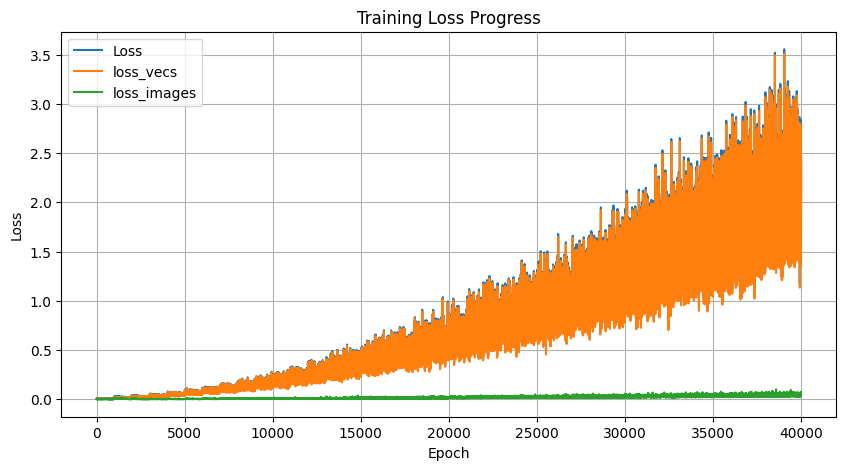

Epoch 39991/40000, Loss: 2.1059, loss_vec: 2.0592, loss_image: 0.0467, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39992/40000, Loss: 2.3056, loss_vec: 2.2686, loss_image: 0.0371, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39993/40000, Loss: 2.4846, loss_vec: 2.4333, loss_image: 0.0513, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39994/40000, Loss: 1.6232, loss_vec: 1.5894, loss_image: 0.0337, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39995/40000, Loss: 1.7040, loss_vec: 1.6069, loss_image: 0.0971, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39996/40000, Loss: 2.9277, loss_vec: 2.8807, loss_image: 0.0470, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39997/40000, Loss: 2.3687, l

In [16]:
# NotdecoderHight
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt


transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)


# エポック数と最小ロスの設定
epochs = 40000
best_loss = float('inf')
shift_range = 1

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs = []
loss_images = []
loss_hightVecs = []
for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 1000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)

    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer(moving_images, displacement_field)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D(moving_images, moving_images2)

    loss_vec = MSE_Loss(displacement_field, Vec) * B
    loss_image = MSE_Loss(moving_images2, transformed_image) * A
    
    loss = loss_vec + loss_image

    # 逆伝播
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        torch.save(
            model3D.state_dict(),
            f'a.pth'
        )
        

    losses.append(loss.cpu().item())
    loss_vecs.append(loss_vec.cpu().item())
    loss_images.append(loss_image.cpu().item())

    # 100エポックごとにグラフを更新
    if epoch % 10 == 0:
        clear_output(wait=True)  # 出力をリフレッシュ
        plt.figure(figsize=(10,5))
        plt.plot(losses, label='Loss')
        plt.plot(loss_vecs, label='loss_vecs')
        plt.plot(loss_images, label='loss_images')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Progress")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec: {loss_vec:.4f}, loss_image: {loss_image:.4f}, Shift Range: ±{shift_range} pixels")


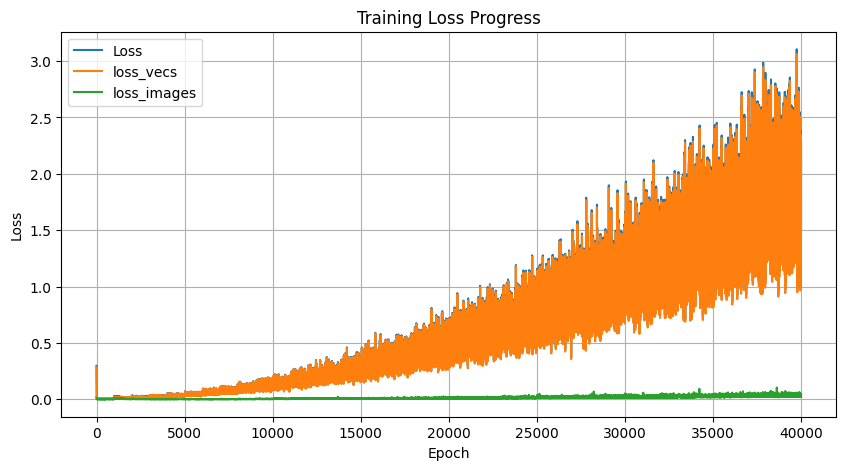

Epoch 39991/40000, Loss: 2.1204, loss_vec: 2.0927, loss_image: 0.0277, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39992/40000, Loss: 2.0401, loss_vec: 2.0083, loss_image: 0.0318, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39993/40000, Loss: 2.0083, loss_vec: 1.9757, loss_image: 0.0326, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39994/40000, Loss: 2.0938, loss_vec: 2.0571, loss_image: 0.0367, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39995/40000, Loss: 1.8570, loss_vec: 1.8267, loss_image: 0.0303, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39996/40000, Loss: 1.7244, loss_vec: 1.6883, loss_image: 0.0361, Shift Range: ±40 pixels
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 39997/40000, Loss: 2.9127, l

In [17]:
# NotdecoderHight
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt


transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)


# エポック数と最小ロスの設定
epochs = 40000
best_loss = float('inf')
shift_range = 1

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs = []
loss_images = []
loss_hightVecs = []
for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 1000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)

    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer(moving_images, displacement_field)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D(moving_images, moving_images2)

    loss_vec = MSE_Loss(displacement_field, Vec) * B
    loss_image = MSE_Loss(moving_images2, transformed_image) * A
    
    loss = loss_vec + loss_image

    # 逆伝播
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        torch.save(
            model3D.state_dict(),
            f'a.pth'
        )
        

    losses.append(loss.cpu().item())
    loss_vecs.append(loss_vec.cpu().item())
    loss_images.append(loss_image.cpu().item())

    # 100エポックごとにグラフを更新
    if epoch % 10 == 0:
        clear_output(wait=True)  # 出力をリフレッシュ
        plt.figure(figsize=(10,5))
        plt.plot(losses, label='Loss')
        plt.plot(loss_vecs, label='loss_vecs')
        plt.plot(loss_images, label='loss_images')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Progress")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec: {loss_vec:.4f}, loss_image: {loss_image:.4f}, Shift Range: ±{shift_range} pixels")


In [18]:
model3D = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
model3D.load_state_dict(torch.load('a.pth', map_location=device))
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

from tqdm.notebook import tqdm

# エポック数と最小ロスの設定
epochs = 10000

# ロスや他のメトリクスを記録するリスト
losses = []

for epoch in tqdm(range(epochs)):

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32).to(device)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D(moving_images, fixed_images)

    # 損失を計算
    loss = MSE_Loss(fixed_images, transformed_image)

    # 逆伝播
    loss.backward()
    optimizer.step()

    # モデルを保存
    torch.save(model3D.state_dict(), 'a2.pth')

    # エポックごとのロスを保存
    losses.append(loss.cpu().item())
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

5
6
7
6
7
6
7
6
7
6
7
64
128
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
11
11
11
[32, 64, 64]


  0%|          | 0/10000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_14856\110661550.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)
C:\Users\user\AppData\Local\Temp\ipykernel_14856\110661550.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32).to(device)


torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 1/10000, Loss: 0.0292
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 2/10000, Loss: 0.0452
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 3/10000, Loss: 0.0069
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 4/10000, Loss: 0.0077
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 5/10000, Loss: 0.0129
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 6/10000, Loss: 0.0108
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 7/10000, Loss: 0.0113
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 8/10000, Loss: 0.0103
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 9/10000, Loss: 0.0089
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 10/10000, Loss: 0.0055
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128,